In [2]:
import kagglehub
from ultralytics import YOLO
from huggingface_hub import hf_hub_download
from pathlib import Path
from PIL import Image
from IPython.display import display

In [3]:
# Download latest version
path = kagglehub.dataset_download("ismailnasri20/driver-drowsiness-dataset-ddd")

print("Path to dataset files:", path)

100%|██████████| 2.58G/2.58G [01:57<00:00, 23.7MB/s]

Extracting files...


Path to dataset files: C:\Users\itsan\.cache\kagglehub\datasets\ismailnasri20\driver-drowsiness-dataset-ddd\versions\1


Using image: C:\Users\itsan\.cache\kagglehub\datasets\ismailnasri20\driver-drowsiness-dataset-ddd\versions\1\Driver Drowsiness Dataset (DDD)\Drowsy\A0001.png


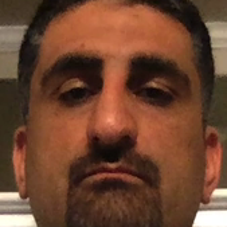


image 1/1 C:\Users\itsan\.cache\kagglehub\datasets\ismailnasri20\driver-drowsiness-dataset-ddd\versions\1\Driver Drowsiness Dataset (DDD)\Drowsy\A0001.png: 224x224 Drowsy 1.00, Non Drowsy 0.00, 65.2ms
Speed: 0.9ms preprocess, 65.2ms inference, 0.0ms postprocess per image at shape (1, 3, 224, 224)
Prediction: Drowsy with confidence 1.0000


In [ ]:
# Download model weights from Hugging Face Hub
model_path = hf_hub_download(repo_id='mosesb/drowsiness-detection-yolo-cls', filename='best.pt')
model = YOLO(model_path)

# Grab the first image from the dataset
dataset_dir = Path(path) / "Driver Drowsiness Dataset (DDD)"
first_image_path = sorted(dataset_dir.rglob("*.png"))[0]
print(f"Using image: {first_image_path}")

# Display the image
img = Image.open(first_image_path)
display(img)

# Run inference
results = model.predict(first_image_path)

# Print the top prediction
probs = results[0].probs
top1_class_index = probs.top1
top1_confidence = probs.top1conf
class_name = model.names[top1_class_index]

print(f"Prediction: {class_name} with confidence {top1_confidence:.4f}")